<a href="https://colab.research.google.com/github/Abhinavharle45-hub/pagu-infobyte/blob/main/EDA_Retail_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TASK 1: EDA on Retail Sales Data

**Objective:** Perform a thorough Exploratory Data Analysis on a retail sales dataset to uncover patterns, customer behaviour trends, and actionable business insights.

**Tech Stack:** Python, pandas, matplotlib, seaborn, Jupyter Notebook

## 1. Setup: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
%matplotlib inline

print("Libraries loaded successfully")

Libraries loaded successfully


## 2. Load the Dataset

**If you're in Google Colab**, run the upload cell below and pick `retail_sales_data.csv` from your computer.
This avoids filename mismatches (no more "(1)" duplicates) because we grab the exact name Colab assigns.

**If you're in local Jupyter**, just make sure the CSV is in the same folder as this notebook, then skip the upload cell and run the `pd.read_csv` cell directly.

In [2]:
# Run this cell ONLY if you're in Google Colab
from google.colab import files
uploaded = files.upload()

# Automatically grabs whatever filename was uploaded
import os
csv_filename = list(uploaded.keys())[0]
print("Uploaded file name:", csv_filename)

Saving retail_sales_data (1).csv to retail_sales_data (1).csv
Uploaded file name: retail_sales_data (1).csv


In [3]:
# Load the dataset
# If you ran the Colab upload cell above, this uses that exact filename automatically.
# If you're in local Jupyter, replace csv_filename with "retail_sales_data.csv"

try:
    df = pd.read_csv(csv_filename)
except NameError:
    df = pd.read_csv("retail_sales_data.csv")

print("Dataset loaded. Shape:", df.shape)
df.head()

Dataset loaded. Shape: (2000, 14)


,order_id,order_date,customer_id,customer_age,customer_gender,customer_type,region,product_name,category,quantity,unit_price,discount,sales,profit
0,ORD00980,2023-01-01,CUST0074,33.0,Female,Returning,West,Dumbbell Set,Sports,3,16.54,0.00,49.62,17.11
1,ORD01976,2023-01-01,CUST0062,18.0,Female,Returning,North,Non-stick Pan,Home & Kitchen,4,30.12,0.00,120.48,24.28
2,ORD00649,2023-01-01,CUST0214,29.0,Male,Returning,North,Wireless Earbuds,Electronics,5,77.38,0.15,328.86,73.79
3,ORD00756,2023-01-01,CUST0021,40.0,Female,Returning,South,Smartphone Case,Electronics,2,62.48,0.15,106.22,31.30
4,ORD01138,2023-01-01,CUST0217,37.0,Male,Returning,North,Shampoo Bottle,Beauty,3,5.75,0.00,17.25,3.77


## 3. Initial Inspection: Shape, Dtypes, Null Values

In [4]:
print("Shape (rows, columns):", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())

Shape (rows, columns): (2000, 14)

Column dtypes:
order_id            object
order_date          object
customer_id         object
customer_age       float64
customer_gender     object
customer_type       object
region              object
product_name        object
category            object
quantity             int64
unit_price         float64
discount           float64
sales              float64
profit             float64
dtype: object

Missing values per column:
order_id            0
order_date          0
customer_id         0
customer_age       40
customer_gender     0
customer_type       0
region             40
product_name        0
category            0
quantity            0
unit_price          0
discount           40
sales               0
profit              0
dtype: int64


**Observation:** *(write your own — e.g. how many rows/columns, which columns have missing values, any dtype issues such as dates stored as text)*

## 4. Descriptive Statistics

In [5]:
print("Numerical columns summary:")
display(df.describe())

print("\nCategorical columns summary:")
display(df.describe(include='object'))

print("\nMedian values:")
print(df.median(numeric_only=True))

print("\nMode values:")
print(df.mode(numeric_only=True).iloc[0])

Numerical columns summary:


,customer_age,quantity,unit_price,discount,sales,profit
count,1960.000000,2000.000000,2000.000000,1960.000000,2000.000000,2000.000000
mean,33.706122,3.043000,46.095095,0.031505,136.619375,29.923785
std,10.450709,1.462949,26.684745,0.055490,109.673197,27.055642
min,16.000000,1.000000,5.130000,0.000000,5.190000,0.730000
25%,26.000000,2.000000,25.312500,0.000000,54.717500,10.670000
50%,33.000000,3.000000,41.325000,0.000000,106.410000,21.515000
75%,41.000000,4.000000,61.160000,0.050000,190.432500,39.820000
max,67.000000,7.000000,119.700000,0.200000,726.150000,181.300000



Categorical columns summary:


,order_id,order_date,customer_id,customer_gender,customer_type,region,product_name,category
count,2000,2000,2000,2000,2000,1960,2000,2000
unique,2000,671,399,2,2,4,25,5
top,ORD00871,2023-02-08,CUST0169,Female,Returning,South,USB-C Charger,Electronics
freq,1,10,13,1040,1281,521,116,557



Median values:
customer_age     33.000
quantity          3.000
unit_price       41.325
discount          0.000
sales           106.410
profit           21.515
dtype: float64

Mode values:
customer_age    16.00
quantity         1.00
unit_price      15.58
discount         0.00
sales           31.23
profit           4.78
Name: 0, dtype: float64


**Observation:** *(comment on spread/std, any skew you notice comparing mean vs median)*

## 5. Time Series Analysis: Monthly and Quarterly Sales Trends

/tmp/ipykernel_1889/584926251.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df_ts['sales'].resample('M').sum()


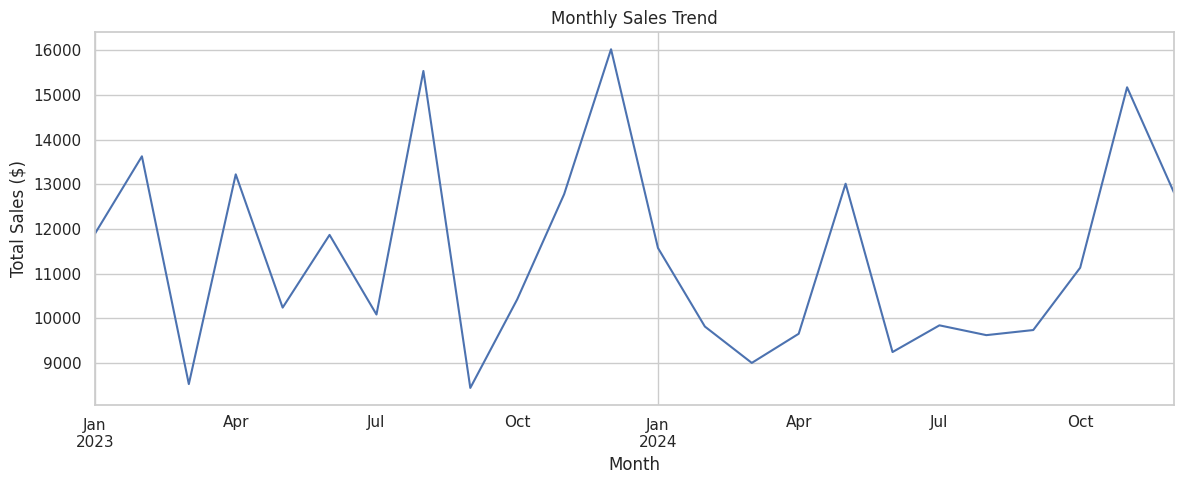

In [6]:
df['order_date'] = pd.to_datetime(df['order_date'])
df_ts = df.set_index('order_date')

monthly_sales = df_ts['sales'].resample('M').sum()

plt.figure(figsize=(12,5))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1889/814077647.py:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_sales = df_ts['sales'].resample('Q').sum()


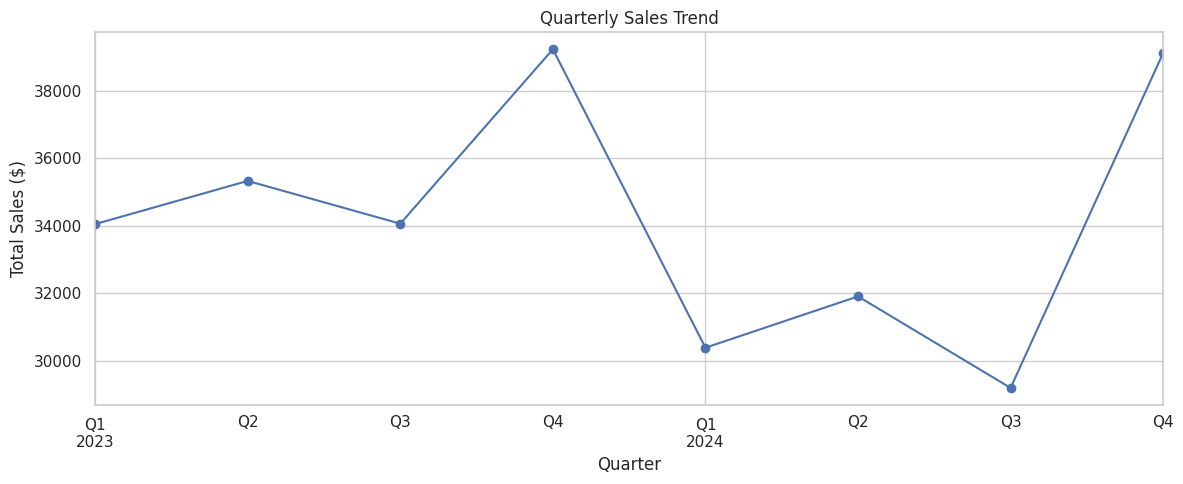

In [7]:
quarterly_sales = df_ts['sales'].resample('Q').sum()

plt.figure(figsize=(12,5))
quarterly_sales.plot(marker='o')
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales ($)")
plt.tight_layout()
plt.show()

**Observation:** *(note peaks/dips, any seasonality you can see, e.g. holiday spikes in Nov/Dec)*

## 6. Customer Demographics Analysis

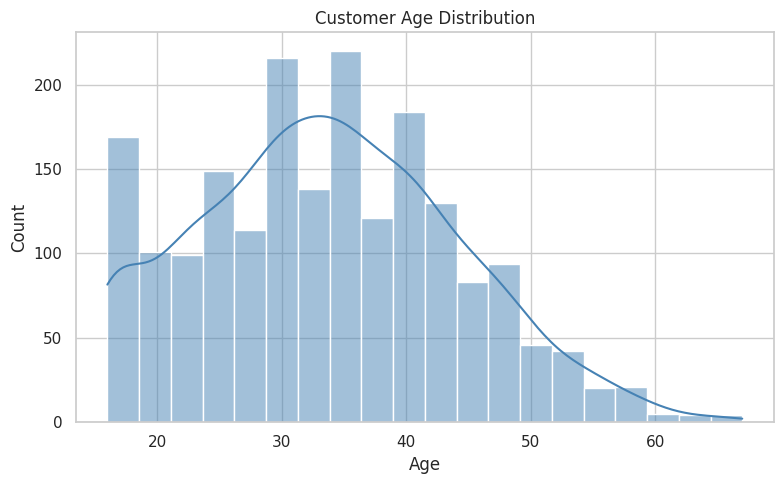

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['customer_age'].dropna(), bins=20, kde=True, color='steelblue')
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1889/2394197548.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='customer_gender', data=df, palette='Set2')


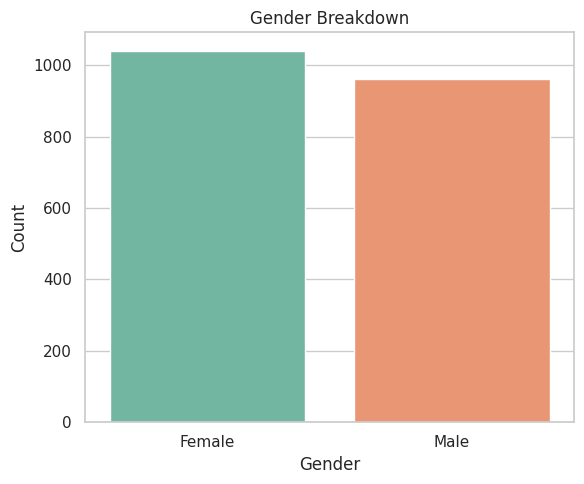

In [9]:
plt.figure(figsize=(6,5))
sns.countplot(x='customer_gender', data=df, palette='Set2')
plt.title("Gender Breakdown")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**Observation:** *(which age band dominates, gender split observations)*

## 7. Product Analysis

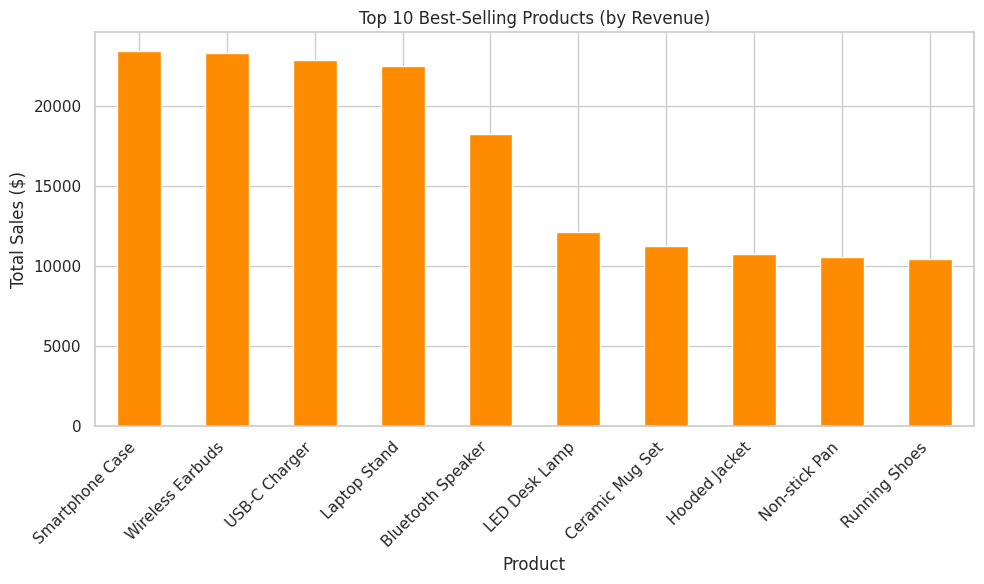

In [10]:
top_products = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_products.plot(kind='bar', color='darkorange')
plt.title("Top 10 Best-Selling Products (by Revenue)")
plt.xlabel("Product")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

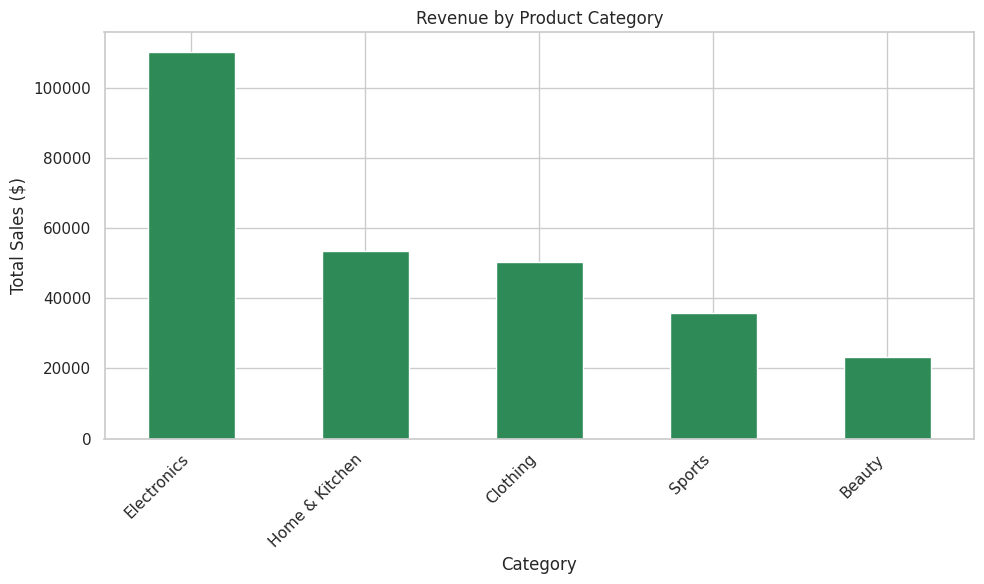

In [11]:
category_revenue = df.groupby('category')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
category_revenue.plot(kind='bar', color='seagreen')
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Observation:** *(which products/categories bring in the most revenue, anything surprising)*

## 8. Correlation Heatmap

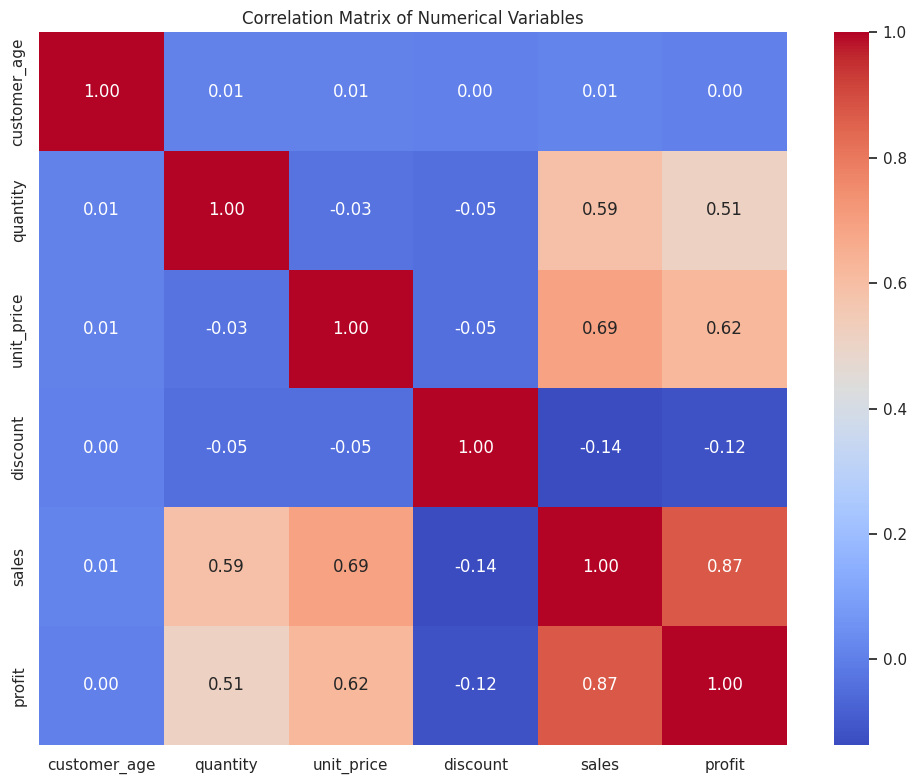

In [12]:
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

**Observation:** *(call out any strong correlations, e.g. quantity vs sales, discount vs profit, and anything counterintuitive)*

## 9. Additional Visualisation: Average Sales by Day of Week

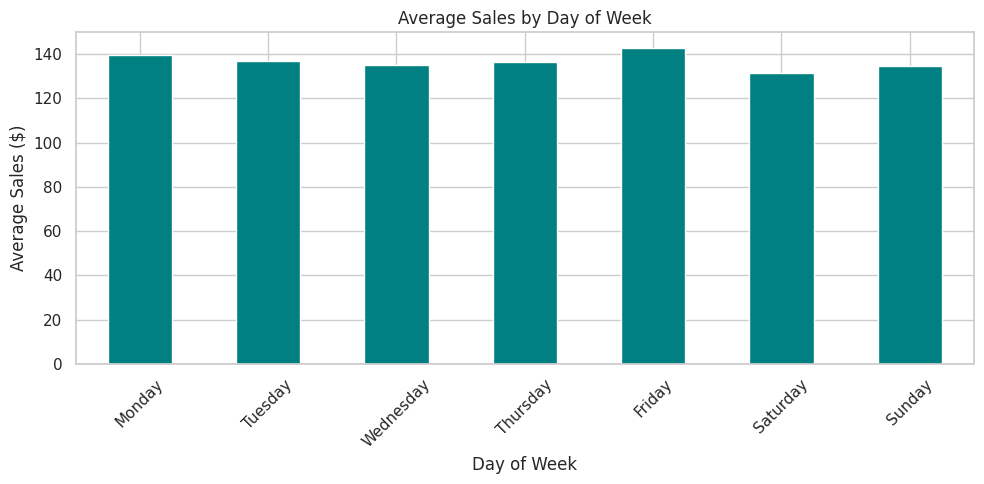

In [13]:
df['day_of_week'] = df['order_date'].dt.day_name()

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_sales = df.groupby('day_of_week')['sales'].mean().reindex(dow_order)

plt.figure(figsize=(10,5))
dow_sales.plot(kind='bar', color='teal')
plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:** *(describe what you actually see — flat, weekend spike, etc. — and what it might mean for staffing/promotions)*

## 10. Conclusion: Actionable Business Recommendations

*(Fill in with your own findings from the charts above. Example structure:)*

1. **Seasonal promotion timing:** Sales show a noticeable increase in November-December, suggesting the business should increase inventory and marketing spend ahead of this period.

2. **Category focus:** [Category] generates the highest revenue — consider prioritizing supply chain and marketing budget toward this category.

3. **Discount strategy:** Higher discount levels correlate with [lower / similar] profit margins — consider capping discounts at [X]% to protect profitability.

4. **Customer targeting:** The [age range] age group is the largest customer segment — tailor marketing campaigns and product selection toward this group.